## 2. Data Exploration on the Combined Data Set and Process


In [154]:
# !pip install shap

In [66]:
# If you're using the default bucket, set DEFAULT_BUCKET = True; otherwise, if you're using a specific bucket, set it to False instead
DEFAULT_BUCKET = True

In [155]:
#import libraries
import boto3
import sagemaker
import pandas as pd
import os
import tqdm
from tqdm import tqdm
import math
import scipy.stats as stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from io import StringIO
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as smo
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

sess = sagemaker.Session()
if DEFAULT_BUCKET is True:
    # Code to read/write using the default bucket
    bucket = sess.default_bucket()
else:
    # Code to use a previously existing bucket
    bucket = "usdmsaai540-spring2026-team1"
s3 = boto3.resource("s3")

role = sagemaker.get_execution_role()
region = boto3.Session().region_name
account_id = boto3.client("sts").get_caller_identity().get("Account")

sm = boto3.Session().client(service_name="sagemaker", region_name=region)

In [68]:
s3_private_path_csv = "s3://{}/CCPP/data/processeddata".format(bucket)
print(s3_private_path_csv)

s3://sagemaker-us-east-1-814259697872/CCPP/data/processeddata


### EDA:

In [69]:
gt_all_years = pd.read_csv(f'{s3_private_path_csv}/gas_turbine.csv')

In [70]:
gt_all_years.head()

,DT,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,2011-01-01T00:00:00,4.5878,1018.7,83.675,3.5758,23.979,1086.2,549.83,134.67,11.898,0.32663,81.952
1,2011-01-01T01:00:00,4.2932,1018.3,84.235,3.5709,23.951,1086.1,550.05,134.67,11.892,0.44784,82.377
2,2011-01-01T02:00:00,3.9045,1018.4,84.858,3.5828,23.990,1086.5,550.19,135.10,12.042,0.45144,83.776
3,2011-01-01T03:00:00,3.7436,1018.3,85.434,3.5808,23.911,1086.5,550.17,135.03,11.990,0.23107,82.505
4,2011-01-01T04:00:00,3.7516,1017.8,85.182,3.5781,23.917,1085.9,550.00,134.67,11.910,0.26747,82.028


In [104]:
s3_private_uci_data_path_csv =  "s3://usdmsaai540-spring2026-team1/CCPP/data/uci_dataset/"
print(s3_private_uci_data_path_csv)

s3://usdmsaai540-spring2026-team1/CCPP/data/uci_dataset/


In [106]:
#load weather infomation
weather_hourly_turkey = pd.read_csv(os.path.join(s3_private_uci_data_path_csv,'CCPP 2011-2015 Full Weather Data.csv'))
weather_hourly_turkey.head()

,name,datetime,temp,feelslike,dew,humidity,precip,precipprob,preciptype,snow,...,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,conditions,icon,stations
0,"Marmara Ereglisi, Turkey",2011-01-01T00:00:00,-2.3,-2.3,-4.7,83.98,0.0,0,NaN,0.0,...,1022.2,0.0,12.0,NaN,NaN,NaN,NaN,Clear,clear-night,"17056099999,LTBU,17054099999,17115099999,17060..."
1,"Marmara Ereglisi, Turkey",2011-01-01T01:00:00,-1.6,-1.6,-4.7,79.28,0.0,0,NaN,0.0,...,1021.4,0.0,12.0,NaN,NaN,NaN,NaN,Clear,clear-night,"17056099999,LTBU,17054099999,17115099999,17060..."
2,"Marmara Ereglisi, Turkey",2011-01-01T02:00:00,-2.4,-2.4,-4.7,84.56,0.0,0,NaN,0.0,...,1021.3,0.0,11.9,NaN,NaN,NaN,NaN,Clear,clear-night,"17056099999,LTBU,17054099999,17115099999,17060..."
3,"Marmara Ereglisi, Turkey",2011-01-01T03:00:00,0.1,-1.8,-4.6,70.66,0.0,0,NaN,0.0,...,1021.3,0.0,11.9,NaN,NaN,NaN,NaN,Clear,clear-night,"17056099999,LTBU,17054099999,17115099999,17060..."
4,"Marmara Ereglisi, Turkey",2011-01-01T04:00:00,-0.8,-2.6,-3.0,84.94,0.0,0,NaN,0.0,...,1021.2,0.0,9.4,NaN,NaN,NaN,NaN,Clear,clear-night,"17056099999,LTBU,17054099999,17115099999,17060..."


In [107]:
# Confirm number of unique names in weather_data
weather_hourly_turkey['name'].nunique()

1

# Combine weather_data dataframe to gt_all_years when datetimes match

In [108]:
# Convert datetime columns
gt_all_years['DT'] = pd.to_datetime(gt_all_years['DT'])
weather_hourly_turkey['datetime'] = pd.to_datetime(weather_hourly_turkey['datetime'])

# Automatically select all columns except 'datetime' and 'name'
cols_to_add = [col for col in weather_hourly_turkey.columns if col not in ['datetime', 'name']]

# Merge on datetime
gt_merged = gt_all_years.merge(
    weather_hourly_turkey[['datetime'] + cols_to_add],
    left_on='DT',
    right_on='datetime',
    how='left'
).drop(columns=['datetime'])

gt_merged.head()

,DT,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,...,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,conditions,icon,stations
0,2011-01-01 00:00:00,4.5878,1018.7,83.675,3.5758,23.979,1086.2,549.83,134.67,11.898,...,1022.2,0.0,12.0,NaN,NaN,NaN,NaN,Clear,clear-night,"17056099999,LTBU,17054099999,17115099999,17060..."
1,2011-01-01 01:00:00,4.2932,1018.3,84.235,3.5709,23.951,1086.1,550.05,134.67,11.892,...,1021.4,0.0,12.0,NaN,NaN,NaN,NaN,Clear,clear-night,"17056099999,LTBU,17054099999,17115099999,17060..."
2,2011-01-01 02:00:00,3.9045,1018.4,84.858,3.5828,23.990,1086.5,550.19,135.10,12.042,...,1021.3,0.0,11.9,NaN,NaN,NaN,NaN,Clear,clear-night,"17056099999,LTBU,17054099999,17115099999,17060..."
3,2011-01-01 03:00:00,3.7436,1018.3,85.434,3.5808,23.911,1086.5,550.17,135.03,11.990,...,1021.3,0.0,11.9,NaN,NaN,NaN,NaN,Clear,clear-night,"17056099999,LTBU,17054099999,17115099999,17060..."
4,2011-01-01 04:00:00,3.7516,1017.8,85.182,3.5781,23.917,1085.9,550.00,134.67,11.910,...,1021.2,0.0,9.4,NaN,NaN,NaN,NaN,Clear,clear-night,"17056099999,LTBU,17054099999,17115099999,17060..."


In [109]:
gt_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36737 entries, 0 to 36736
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   DT                36737 non-null  datetime64[ns]
 1   AT                36737 non-null  float64       
 2   AP                36737 non-null  float64       
 3   AH                36737 non-null  float64       
 4   AFDP              36737 non-null  float64       
 5   GTEP              36737 non-null  float64       
 6   TIT               36737 non-null  float64       
 7   TAT               36737 non-null  float64       
 8   TEY               36737 non-null  float64       
 9   CDP               36737 non-null  float64       
 10  CO                36737 non-null  float64       
 11  NOX               36737 non-null  float64       
 12  temp              36734 non-null  float64       
 13  feelslike         36734 non-null  float64       
 14  dew               3673

In [110]:
# load  turkish holidays
turkish_holidays = pd.read_csv(os.path.join(s3_private_uci_data_path_csv,"TurkishHolidays.tsv"), sep='\t', encoding='latin1')
turkish_holidays.head()

,Date,DayOfWeek,Name,Type
0,1/1/2000,Saturday,New Year's Day,National Holiday
1,3/20/2000,Monday,March Equinox,Season
2,4/23/2000,Sunday,National Sovereignty and Children's Day,National Holiday
3,5/19/2000,Friday,"Commemoration of Atatürk, Youth and Sports Day",National Holiday
4,6/21/2000,Wednesday,June Solstice,Season


In [111]:
turkish_holidays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 642 entries, 0 to 641
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       642 non-null    object
 1   DayOfWeek  642 non-null    object
 2   Name       642 non-null    object
 3   Type       642 non-null    object
dtypes: object(4)
memory usage: 20.2+ KB


# Combine turkish_holidays with prefix "holiday_" and gt_merged by date
### (Merged dataframe: gt_merged_holidays)

In [112]:
# Convert Turkish holidays Date to datetime.date
turkish_holidays['Date'] = pd.to_datetime(turkish_holidays['Date']).dt.date

# Prefix all holiday columns except 'Date'
holiday_cols = [col for col in turkish_holidays.columns if col != 'Date']
turkish_holidays_prefixed = turkish_holidays.rename(columns={col: f"holiday_{col}" for col in holiday_cols})

# Convert gt_merged DT to datetime.date for merging
gt_merged['DT_date'] = gt_merged['DT'].dt.date

# Merge datasets on date
gt_merged_holidays = gt_merged.merge(
    turkish_holidays_prefixed,
    left_on='DT_date',
    right_on='Date',
    how='left'
)

# Drop the temporary DT_date and duplicate Date column
gt_merged_holidays = gt_merged_holidays.drop(columns=['DT_date', 'Date'])

gt_merged_holidays.head()

,DT,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,...,solarradiation,solarenergy,uvindex,severerisk,conditions,icon,stations,holiday_DayOfWeek,holiday_Name,holiday_Type
0,2011-01-01 00:00:00,4.5878,1018.7,83.675,3.5758,23.979,1086.2,549.83,134.67,11.898,...,NaN,NaN,NaN,NaN,Clear,clear-night,"17056099999,LTBU,17054099999,17115099999,17060...",Saturday,New Year's Day,National Holiday
1,2011-01-01 01:00:00,4.2932,1018.3,84.235,3.5709,23.951,1086.1,550.05,134.67,11.892,...,NaN,NaN,NaN,NaN,Clear,clear-night,"17056099999,LTBU,17054099999,17115099999,17060...",Saturday,New Year's Day,National Holiday
2,2011-01-01 02:00:00,3.9045,1018.4,84.858,3.5828,23.990,1086.5,550.19,135.10,12.042,...,NaN,NaN,NaN,NaN,Clear,clear-night,"17056099999,LTBU,17054099999,17115099999,17060...",Saturday,New Year's Day,National Holiday
3,2011-01-01 03:00:00,3.7436,1018.3,85.434,3.5808,23.911,1086.5,550.17,135.03,11.990,...,NaN,NaN,NaN,NaN,Clear,clear-night,"17056099999,LTBU,17054099999,17115099999,17060...",Saturday,New Year's Day,National Holiday
4,2011-01-01 04:00:00,3.7516,1017.8,85.182,3.5781,23.917,1085.9,550.00,134.67,11.910,...,NaN,NaN,NaN,NaN,Clear,clear-night,"17056099999,LTBU,17054099999,17115099999,17060...",Saturday,New Year's Day,National Holiday


In [113]:
gt_merged_holidays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36737 entries, 0 to 36736
Data columns (total 37 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   DT                 36737 non-null  datetime64[ns]
 1   AT                 36737 non-null  float64       
 2   AP                 36737 non-null  float64       
 3   AH                 36737 non-null  float64       
 4   AFDP               36737 non-null  float64       
 5   GTEP               36737 non-null  float64       
 6   TIT                36737 non-null  float64       
 7   TAT                36737 non-null  float64       
 8   TEY                36737 non-null  float64       
 9   CDP                36737 non-null  float64       
 10  CO                 36737 non-null  float64       
 11  NOX                36737 non-null  float64       
 12  temp               36734 non-null  float64       
 13  feelslike          36734 non-null  float64       
 14  dew   

# NaN Analyzer Fn (all dtypes)
<5% → drop or impute with mean/median.
<br>5–20% → consider imputation.
<br>>20% → consider advanced imputation or dropping column.

In [114]:
# Check NaN, organize with suggestions, fn assisted by ChatGPT for organization 
def analyze_missing(df):
    total_rows = len(df)
    
    na_counts = df.isna().sum()
    na_counts = na_counts[na_counts > 0].sort_values(ascending=False)

    analysis = []
    for col, count in na_counts.items():
        percent_missing = round((count / total_rows) * 100,2)

        if percent_missing < 5:
            suggestion = "Impute with mean/median or drop rows"
        elif percent_missing < 20:
            suggestion = "Impute with mean/median or model-based imputation"
        else:
            suggestion = "Consider dropping column or advanced imputation"

        analysis.append({
            'Column': col,
            'NaN Count': count,
            'Percent NaN': percent_missing,
            'Suggestion': suggestion
        })

    return pd.DataFrame(analysis)

# Execute NaN analysis
missing_analysis = analyze_missing(gt_merged_holidays)
missing_analysis 

,Column,NaN Count,Percent NaN,Suggestion
0,severerisk,36737,100.00,Consider dropping column or advanced imputation
1,preciptype,35606,96.92,Consider dropping column or advanced imputation
2,holiday_Name,34475,93.84,Consider dropping column or advanced imputation
3,holiday_DayOfWeek,34475,93.84,Consider dropping column or advanced imputation
4,holiday_Type,34475,93.84,Consider dropping column or advanced imputation
5,solarenergy,21969,59.80,Consider dropping column or advanced imputation
6,uvindex,21969,59.80,Consider dropping column or advanced imputation
7,solarradiation,21969,59.80,Consider dropping column or advanced imputation
8,windgust,16204,44.11,Consider dropping column or advanced imputation
9,visibility,636,1.73,Impute with mean/median or drop rows


### Feature Engineering:

In [115]:
# holiday type
print("Type of data:", gt_merged_holidays['holiday_Type'].dtype  )
print(gt_merged_holidays['holiday_Type'].unique())
print(gt_merged_holidays['holiday_Type'].value_counts())

Type of data: object
['National Holiday' nan 'Season' 'Half Day' 'Observance'
 'Holiday for Public Servants']
holiday_Type
National Holiday               1337
Season                          384
Half Day                        349
Observance                      144
Holiday for Public Servants      48
Name: count, dtype: int64


In [116]:
numeric_cols = gt_merged_holidays.select_dtypes(include=['number']).columns
numeric_cols 

Index(['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'TEY', 'CDP', 'CO',
       'NOX', 'temp', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
       'snow', 'snowdepth', 'windgust', 'windspeed', 'winddir',
       'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation',
       'solarenergy', 'uvindex', 'severerisk'],
      dtype='object')

In [117]:
categorical_cols = gt_merged_holidays.select_dtypes(include=['object']).columns
categorical_cols

Index(['preciptype', 'conditions', 'icon', 'stations', 'holiday_DayOfWeek',
       'holiday_Name', 'holiday_Type'],
      dtype='object')

In [118]:
# Correlation matrix
correlation_matrix = gt_merged_holidays[numeric_cols].corr()
correlation_matrix

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,...,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk
AT,1.000000,-0.406618,-0.476311,0.252006,0.045882,0.183703,0.281822,-0.091129,0.015311,-0.174310,...,-0.013497,0.073800,-0.148797,-0.320063,-0.275617,0.204692,0.428024,0.427673,0.427446,NaN
AP,-0.406618,1.000000,-0.015107,-0.040379,0.057506,-0.005378,-0.225556,0.118208,0.102613,0.067024,...,0.030956,-0.012873,0.022693,0.331977,0.106651,-0.079268,-0.164053,-0.163764,-0.164169,NaN
AH,-0.476311,-0.015107,1.000000,-0.147868,-0.235167,-0.221786,0.023005,-0.137362,-0.196282,0.106558,...,-0.060368,-0.144773,0.054395,0.057876,0.059092,-0.023960,-0.440137,-0.439957,-0.438696,NaN
AFDP,0.252006,-0.040379,-0.147868,1.000000,0.678466,0.691247,-0.466897,0.665446,0.702536,-0.448384,...,-0.047749,0.045971,-0.032431,-0.063079,-0.012789,0.006918,0.243995,0.243605,0.243445,NaN
GTEP,0.045882,0.057506,-0.235167,0.678466,1.000000,0.874233,-0.699697,0.964125,0.978470,-0.518918,...,-0.019412,0.032216,-0.008327,0.020673,0.072804,-0.059961,0.233091,0.232639,0.232371,NaN
TIT,0.183703,-0.005378,-0.221786,0.691247,0.874233,1.000000,-0.380851,0.910301,0.908471,-0.706289,...,-0.038844,0.052764,-0.038449,-0.033219,0.022576,-0.010833,0.242747,0.242267,0.242019,NaN
TAT,0.281822,-0.225556,0.023005,-0.466897,-0.699697,-0.380851,1.000000,-0.682379,-0.706425,0.058346,...,0.010190,-0.006924,-0.030806,-0.127343,-0.124849,0.094402,0.016187,0.016198,0.016057,NaN
TEY,-0.091129,0.118208,-0.137362,0.665446,0.964125,0.910301,-0.682379,1.000000,0.988778,-0.569829,...,-0.023191,0.027727,0.010325,0.060976,0.112492,-0.084638,0.151543,0.151181,0.151021,NaN
CDP,0.015311,0.102613,-0.196282,0.702536,0.978470,0.908471,-0.706425,0.988778,1.000000,-0.551040,...,-0.020423,0.035694,-0.007130,0.035582,0.079456,-0.060485,0.189776,0.189376,0.189218,NaN
CO,-0.174310,0.067024,0.106558,-0.448384,-0.518918,-0.706289,0.058346,-0.569829,-0.551040,1.000000,...,0.047771,-0.022423,0.037385,0.039157,-0.016527,0.034225,-0.158890,-0.158671,-0.158608,NaN


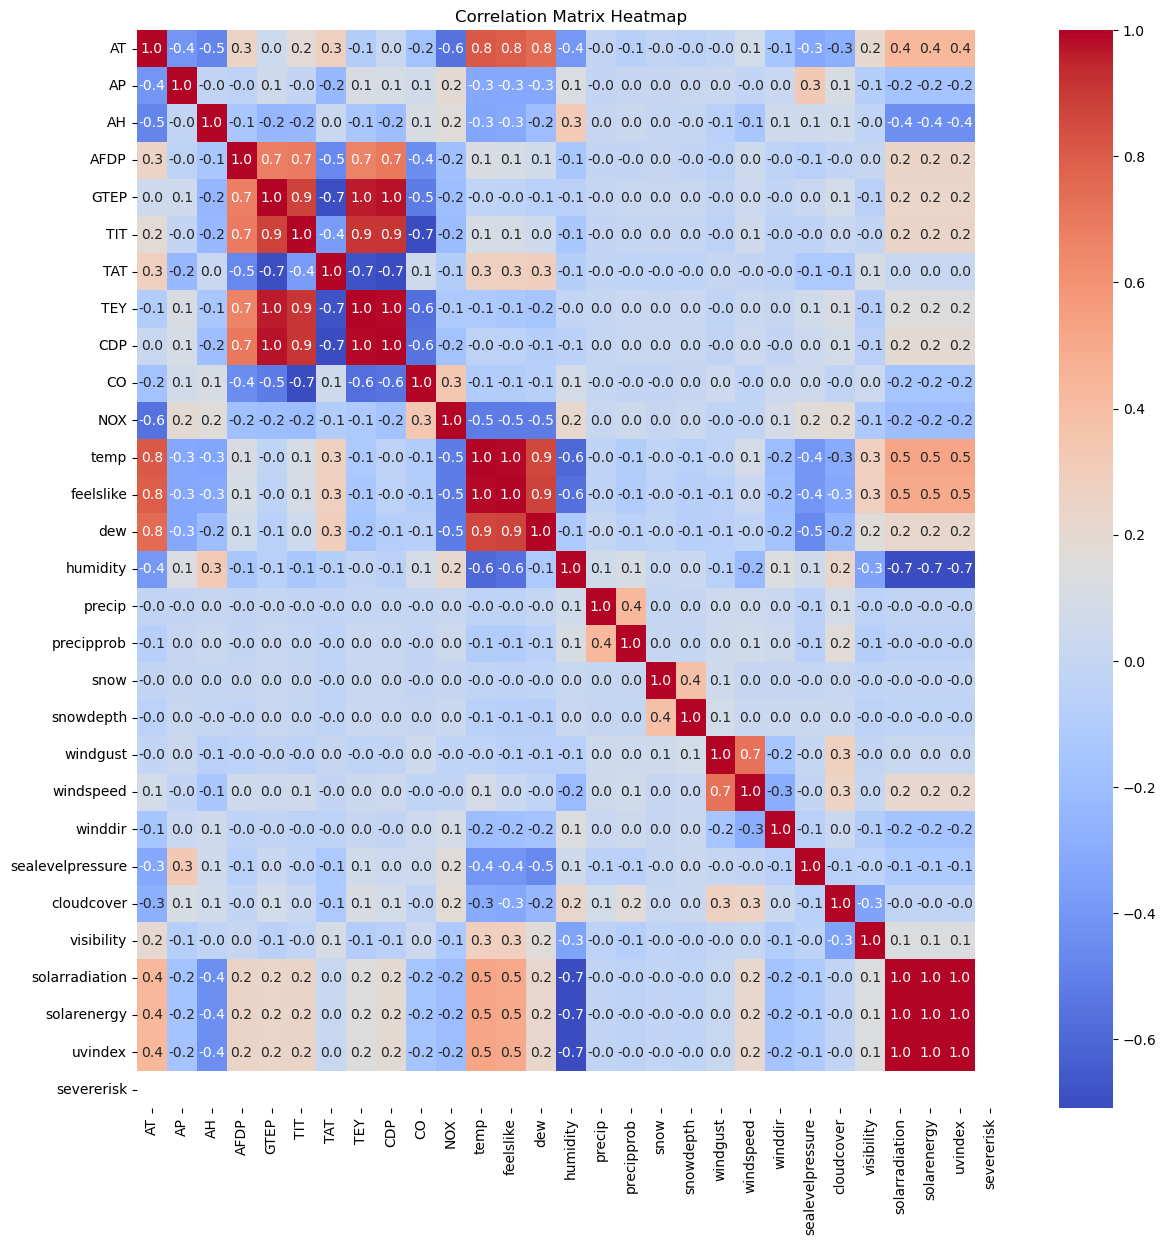

In [119]:
# Visualize correlation matrix using seaborn heatmap
plt.figure(figsize=(14, 14))
sns.heatmap(correlation_matrix, annot=True, fmt=".1f", cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()

In [120]:
# Top correlated features with target variable 'TEY'
target_variable = 'TEY'
correlation_with_target = correlation_matrix[target_variable].sort_values(ascending=False)
correlation_with_target = correlation_with_target.drop(target_variable)  # Remove self-correlation
# Top 10 features
correlation_with_target.head(10)

CDP                 0.988778
GTEP                0.964125
TIT                 0.910301
AFDP                0.665446
solarradiation      0.151543
solarenergy         0.151181
uvindex             0.151021
AP                  0.118208
cloudcover          0.112492
sealevelpressure    0.060976
Name: TEY, dtype: float64

In [121]:
# Top correlated features with target variable 'CO'
target_variable = 'CO'
correlation_with_target = correlation_matrix[target_variable].sort_values(ascending=False)
correlation_with_target = correlation_with_target.drop(target_variable)  # Remove self-correlation
# Top 10 features
correlation_with_target.head(10)

NOX                 0.340609
AH                  0.106558
humidity            0.091598
AP                  0.067024
TAT                 0.058346
windgust            0.047771
sealevelpressure    0.039157
winddir             0.037385
visibility          0.034225
snowdepth           0.010988
Name: CO, dtype: float64

In [122]:
# Top correlated features with target variable 'NOX'
target_variable = 'NOX'
correlation_with_target = correlation_matrix[target_variable].sort_values(ascending=False)
correlation_with_target = correlation_with_target.drop(target_variable)  # Remove self-correlation
# Top 10 features
correlation_with_target.head(10)

CO                  0.340609
humidity            0.210353
AP                  0.191954
cloudcover          0.182037
AH                  0.164631
sealevelpressure    0.163341
winddir             0.085867
precipprob          0.040641
snowdepth           0.026210
precip              0.012225
Name: NOX, dtype: float64

In [123]:
# Feature Correlation matrix within 10 most correlated features for 'TEY'
target_variable = 'TEY'
correlation_with_target = correlation_matrix[target_variable].sort_values(ascending=False)
correlation_with_target = correlation_with_target.drop(target_variable)  # Remove self-correlation
# Top 10 features
correlation_with_target.head(10)
top_10_features = correlation_with_target.head(10).index.tolist()
correlation_matrix_top_10 = correlation_matrix.loc[top_10_features, top_10_features]
correlation_matrix_top_10

,CDP,GTEP,TIT,AFDP,solarradiation,solarenergy,uvindex,AP,cloudcover,sealevelpressure
CDP,1.000000,0.978470,0.908471,0.702536,0.189776,0.189376,0.189218,0.102613,0.079456,0.035582
GTEP,0.978470,1.000000,0.874233,0.678466,0.233091,0.232639,0.232371,0.057506,0.072804,0.020673
TIT,0.908471,0.874233,1.000000,0.691247,0.242747,0.242267,0.242019,-0.005378,0.022576,-0.033219
AFDP,0.702536,0.678466,0.691247,1.000000,0.243995,0.243605,0.243445,-0.040379,-0.012789,-0.063079
solarradiation,0.189776,0.233091,0.242747,0.243995,1.000000,0.999735,0.996792,-0.164053,-0.018899,-0.114104
solarenergy,0.189376,0.232639,0.242267,0.243605,0.999735,1.000000,0.996504,-0.163764,-0.018919,-0.113866
uvindex,0.189218,0.232371,0.242019,0.243445,0.996792,0.996504,1.000000,-0.164169,-0.018663,-0.114198
AP,0.102613,0.057506,-0.005378,-0.040379,-0.164053,-0.163764,-0.164169,1.000000,0.106651,0.331977
cloudcover,0.079456,0.072804,0.022576,-0.012789,-0.018899,-0.018919,-0.018663,0.106651,1.000000,-0.067174
sealevelpressure,0.035582,0.020673,-0.033219,-0.063079,-0.114104,-0.113866,-0.114198,0.331977,-0.067174,1.000000


In [124]:
data_set_filtered = gt_merged_holidays[top_10_features].copy()
data_set_filtered['Target'] = gt_merged_holidays['TEY']

In [125]:
data_set_filtered.dropna(inplace=True)
feature_set_filtered=data_set_filtered.drop(columns=['Target'])
target_variable=data_set_filtered['Target']

In [126]:
# Variance Inflation Factor (VIF) Calculation
vif_data = pd.DataFrame()
vif_data["feature"] = top_10_features
vif_data["VIF"] = [variance_inflation_factor(feature_set_filtered[top_10_features].values, i) for i in range(len(top_10_features))]
vif_data   

,feature,VIF
0,CDP,2599.106985
1,GTEP,552.765152
2,TIT,18714.230417
3,AFDP,102.213900
4,solarradiation,3183.187735
5,solarenergy,2917.171186
6,uvindex,240.168407
7,AP,23487.153026
8,cloudcover,3.054201
9,sealevelpressure,25876.037282


In [127]:
high_vif_features = vif_data[vif_data["VIF"] > 1000]["feature"].tolist()
feature_set_filtered.drop(columns=high_vif_features, inplace=True)

In [128]:
vif_data = pd.DataFrame()
vif_data["feature"] = feature_set_filtered.columns
vif_data["VIF"] = [variance_inflation_factor(feature_set_filtered.values, i) for i in range(len(feature_set_filtered.columns))]
vif_data    

,feature,VIF
0,GTEP,74.654025
1,AFDP,70.592474
2,uvindex,1.616495
3,cloudcover,2.783055


In [129]:
csv_buffer = StringIO()
data_set_filtered.to_csv(csv_buffer,index=False)
s3 = boto3.client('s3')
s3.put_object(
    Bucket=bucket,
    Key="CCPP/data/feature_set/clean_data.csv",
    Body=csv_buffer.getvalue()
)

{'ResponseMetadata': {'RequestId': '5V594MRA7ACKTM0X',
  'HostId': 'lUdek5mWkGYxGidOUpQzDbvkK0uqjSHqlQMwgW+4VP2DpUncioN5ukCP28PEyxVoumsCSTqDRXM=',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amz-id-2': 'lUdek5mWkGYxGidOUpQzDbvkK0uqjSHqlQMwgW+4VP2DpUncioN5ukCP28PEyxVoumsCSTqDRXM=',
   'x-amz-request-id': '5V594MRA7ACKTM0X',
   'date': 'Tue, 17 Feb 2026 08:35:49 GMT',
   'x-amz-server-side-encryption': 'AES256',
   'etag': '"48eeb659c0ec881228fc487a0bb0ad88"',
   'x-amz-checksum-crc32': 'T6f3rQ==',
   'x-amz-checksum-type': 'FULL_OBJECT',
   'content-length': '0',
   'server': 'AmazonS3'},
  'RetryAttempts': 0},
 'ETag': '"48eeb659c0ec881228fc487a0bb0ad88"',
 'ChecksumCRC32': 'T6f3rQ==',
 'ChecksumType': 'FULL_OBJECT',
 'ServerSideEncryption': 'AES256'}

# Data Cleaning
## Creates df_cleaned dataframe
## Drop rows with low null value counts

In [92]:
# Get columns suggested for dropping rows
cols_to_check = missing_analysis[missing_analysis['Suggestion'] == "Impute with mean/median or drop rows"]['Column'].tolist()

# Drop rows where any of these columns are NaN
df_cleaned = gt_merged_holidays.dropna(subset=cols_to_check).copy()

# Re-check NaN analysis
missing_analysis = analyze_missing(df_cleaned)
missing_analysis

,Column,NaN Count,Percent NaN,Suggestion
0,severerisk,36096,100.00,Consider dropping column or advanced imputation
1,preciptype,34965,96.87,Consider dropping column or advanced imputation
2,holiday_Type,33900,93.92,Consider dropping column or advanced imputation
3,holiday_DayOfWeek,33900,93.92,Consider dropping column or advanced imputation
4,holiday_Name,33900,93.92,Consider dropping column or advanced imputation
5,solarenergy,21735,60.21,Consider dropping column or advanced imputation
6,uvindex,21735,60.21,Consider dropping column or advanced imputation
7,solarradiation,21735,60.21,Consider dropping column or advanced imputation
8,windgust,15971,44.25,Consider dropping column or advanced imputation


# Weather data columns missing data 44% and up will be removed from df_cleaned:
severerisk

preciptype

solarenergy

uvindex

solarradiation

windgust


In [93]:
# Get non-holiday columns suggested for dropping entirely
cols_to_drop = missing_analysis[
    (missing_analysis['Suggestion'] == "Consider dropping column or advanced imputation") &
    (~missing_analysis['Column'].str.startswith('holiday'))
]['Column'].tolist()

# Drop those columns from df_cleaned
df_cleaned = df_cleaned.drop(columns=cols_to_drop)

# Execute NaN analysis
missing_analysis = analyze_missing(df_cleaned)
missing_analysis

,Column,NaN Count,Percent NaN,Suggestion
0,holiday_DayOfWeek,33900,93.92,Consider dropping column or advanced imputation
1,holiday_Name,33900,93.92,Consider dropping column or advanced imputation
2,holiday_Type,33900,93.92,Consider dropping column or advanced imputation


# Holiday data will be used to create encoded_holiday column
# 1= holiday 0 = not a holiday

In [95]:
# Check any duplicated rows in merged, clean dataframe
df_cleaned.duplicated().sum()

0

In [59]:
# Check statistics
df_cleaned.describe().T

,count,mean,min,25%,50%,75%,max,std
DT,36096,2013-06-23 08:49:21.303191552,2011-01-01 00:00:00,2012-03-28 18:45:00,2013-06-13 21:30:00,2014-09-11 20:15:00,2015-12-31 04:00:00,NaN
AT,36096.0,17.665762,-6.2348,11.718,17.703,23.6515,37.103,7.46657
AP,36096.0,1013.100442,985.85,1008.8,1012.6,1017.1,1036.6,6.49612
AH,36096.0,77.737997,24.085,68.091,80.316,89.214,100.2,14.454239
AFDP,36096.0,3.924539,2.0874,3.349375,3.93895,4.3772,7.6106,0.776325
GTEP,36096.0,25.584523,17.698,23.167,25.11,29.146,40.716,4.201894
TIT,36096.0,1081.522914,1000.8,1072.1,1086.0,1097.4,1100.8,17.529487
TAT,36096.0,546.116331,511.04,544.63,549.88,550.04,550.61,6.880449
TEY,36096.0,133.612139,100.02,124.91,133.74,144.32,179.5,15.624884
CDP,36096.0,12.066908,9.8518,11.452,11.967,12.89,15.159,1.089966


# Data Scaling Analysis Fn (numerical dtypes)
Range/Std ratio > 10 → flag scaling needed.

Min >= 0 → MinMaxScaler suggested.

Otherwise → StandardScaler suggested.

In [96]:
# Function to assist with determining if any scaling may be needed for model training
# Functions organization assisted by ChatGPT
def analyze_scaling(df, threshold_ratio=10):
    """
    Analyze numeric columns and suggest scaling.
    
    Parameters:
    - df: pandas DataFrame
    - threshold_ratio: ratio between max and min difference to recommend scaling
    
    Returns:
    - pandas DataFrame with statistics and scaling suggestion
    """
    numeric_cols = df.select_dtypes(include='number').columns
    stats_list = []

    for col in numeric_cols:
        series = df[col].dropna()
        col_min = series.min()
        col_max = series.max()
        col_mean = series.mean()
        col_std = series.std()
        col_range = col_max - col_min
        
        # Rough rule: if range/std difference is high, scaling recommended
        recommend_scaling = 'No'
        scaling_type = None
        
        if col_std > 0:
            range_to_std_ratio = col_range / col_std
        else:
            range_to_std_ratio = 0
        
        # Heuristic: if range is much bigger than std, scaling may help
        if range_to_std_ratio > threshold_ratio:
            recommend_scaling = 'Yes'
            # Suggest StandardScaler if mean far from 0, MinMax if values are bounded
            if col_min >= 0:
                scaling_type = 'MinMaxScaler'
            else:
                scaling_type = 'StandardScaler'
        
        stats_list.append({
            'Column': col,
            'Min': col_min,
            'Max': col_max,
            'Mean': col_mean,
            'Std': col_std,
            'Range': col_range,
            'Range/Std': range_to_std_ratio,
            'Scaling Recommended': recommend_scaling,
            'Suggested Scaler': scaling_type
        })
    
    return pd.DataFrame(stats_list).sort_values(by='Range/Std', ascending=False)

# Execute scaling analysis
scale_analysis = analyze_scaling(df_cleaned)
scale_analysis

,Column,Min,Max,Mean,Std,Range,Range/Std,Scaling Recommended,Suggested Scaler
17,snow,0.000000,8.9200,0.000692,0.050239,8.920000,177.552786,Yes,MinMaxScaler
18,snowdepth,0.000000,8.9200,0.004783,0.138830,8.920000,64.251417,Yes,MinMaxScaler
15,precip,0.000000,52.1830,0.070929,0.948743,52.183000,55.002261,Yes,MinMaxScaler
9,CO,0.000388,44.1030,2.369218,2.270993,44.102612,19.419970,Yes,MinMaxScaler
10,NOX,25.905000,119.9100,65.415725,11.693089,94.005000,8.039364,No,None
1,AP,985.850000,1036.6000,1013.100442,6.496120,50.750000,7.812355,No,None
21,sealevelpressure,989.300000,1038.4000,1015.703543,6.342495,49.100000,7.741433,No,None
3,AFDP,2.087400,7.6106,3.924539,0.776325,5.523200,7.114548,No,None
19,windspeed,0.000000,63.4000,16.319587,8.940718,63.400000,7.091153,No,None
23,visibility,0.000000,20.0000,11.162467,3.147907,20.000000,6.353427,No,None


## Categorical weather data analysis

In [97]:
# List of categorical weather columns
cat_cols = ['conditions', 'icon', 'stations']

# Print all unique values per column
for col in cat_cols:
    unique_vals = df_cleaned[col].unique()
    print(f"{col} ({len(unique_vals)} unique values):")
    print(unique_vals)
    print()

conditions (11 unique values):
['Clear' 'Partially cloudy' 'Overcast' 'Rain, Overcast'
 'Snow, Rain, Overcast' 'Rain' 'Rain, Partially cloudy'
 'Snow, Rain, Partially cloudy' 'Snow, Overcast' 'Snow, Partially cloudy'
 'Snow, Rain']

icon (9 unique values):
['clear-night' 'clear-day' 'partly-cloudy-day' 'partly-cloudy-night'
 'cloudy' 'rain' 'snow' 'wind' 'fog']

stations (29 unique values):
['17056099999,LTBU,17054099999,17115099999,17060099999'
 '17056099999,17054099999,17115099999,17060099999'
 'LTBU,17054099999,17115099999,17060099999'
 '17056099999,17054099999,17115099999'
 '17054099999,17115099999,17060099999' 'LTBU,17054099999,17115099999'
 'LTBU,17054099999,17060099999' '17056099999,LTBU,17054099999,17060099999'
 '17056099999,17054099999,17060099999'
 '17056099999,LTBU,17115099999,17060099999' '17056099999,LTBU'
 '17056099999,LTBU,17054099999,17115099999' '17056099999,LTBU,17060099999'
 '17115099999,17060099999' '17054099999,17060099999'
 '17056099999,17115099999,17060099999' 'L

# Find unique combo's of weather stations

In [99]:
# Normalize each entry: split, remove duplicates, sort
def normalize_stations(val):
    if pd.isna(val):
        return None
    return ','.join(sorted(set(val.split(','))))

# Apply normalization
normalized = df_cleaned['stations'].apply(normalize_stations)

# Drop NaN and get unique combinations
unique_combos = normalized.dropna().unique()

# Show count
print(f"Number of unique weather station combinations: {len(unique_combos)}\n")

# Print each combo on a new line
for combo in unique_combos:
    print(combo)

Number of unique weather station combinations: 27

17054099999,17056099999,17060099999,17115099999,LTBU
17054099999,17056099999,17060099999,17115099999
17054099999,17060099999,17115099999,LTBU
17054099999,17056099999,17115099999
17054099999,17060099999,17115099999
17054099999,17115099999,LTBU
17054099999,17060099999,LTBU
17054099999,17056099999,17060099999,LTBU
17054099999,17056099999,17060099999
17056099999,17060099999,17115099999,LTBU
17056099999,LTBU
17054099999,17056099999,17115099999,LTBU
17056099999,17060099999,LTBU
17060099999,17115099999
17054099999,17060099999
17056099999,17060099999,17115099999
17060099999,17115099999,LTBU
17060099999,LTBU
17054099999,LTBU
17054099999,17056099999,LTBU
17054099999
17054099999,17056099999
17056099999,17115099999,LTBU
LTBU
17056099999,17060099999
17056099999
17056099999,17115099999


# Encoding - Feature Engineering:
## Encode unique 'weather_station' value combos to  integers
## Encoded 'weather_conditions' and 'weather_icon' to integers by unique values
## Encoding "encoded_holiday" column: 1 for 'holiday_Name' non-null, 0 for 'holiday_Name' null
## Encode datetime to morning: 1, afternoon:2, night: 3
## Ecode datetime to spring:1, summer:2 fall:3, winter: 4

In [101]:
# Create a mapping from unique normalized combos to integer codes
combo_to_code = {combo: i for i, combo in enumerate(unique_combos)}

# Encode each row into a new column
df_cleaned['encoded_weather_stations'] = normalized.map(combo_to_code)


# Encode categorical columns based on their unique values
for col in ['conditions', 'icon']:
    unique_vals = df_cleaned[col].dropna().unique()
    val_to_code = {val: i for i, val in enumerate(unique_vals)}
    df_cleaned[f'encoded_{col}'] = df_cleaned[col].map(val_to_code)


# 1 if holiday_Name exists, 0 if NaN
df_cleaned['encoded_holiday'] = df_cleaned['holiday_Name'].notnull().astype(int)

# ---- Encode time of day ----
# morning: 1 (05–11), afternoon: 2 (12–17), night: 3 (18–04)
df_cleaned['encoded_time_of_day'] = df_cleaned['DT'].dt.hour.apply(
    lambda h: 1 if 5 <= h < 12 else (2 if 12 <= h < 18 else 3)
)

# ---- Encode seasons ----
# spring: 1, summer: 2, fall: 3, winter: 4
def encode_season(date):
    m = date.month
    if m in [3, 4, 5]:
        return 1  # Spring
    elif m in [6, 7, 8]:
        return 2  # Summer
    elif m in [9, 10, 11]:
        return 3  # Fall
    else:
        return 4  # Winter

df_cleaned['encoded_seasons'] = df_cleaned['DT'].apply(encode_season)

In [102]:
# Column dtype re-check
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36096 entries, 0 to 36736
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DT                        36096 non-null  datetime64[ns]
 1   AT                        36096 non-null  float64       
 2   AP                        36096 non-null  float64       
 3   AH                        36096 non-null  float64       
 4   AFDP                      36096 non-null  float64       
 5   GTEP                      36096 non-null  float64       
 6   TIT                       36096 non-null  float64       
 7   TAT                       36096 non-null  float64       
 8   TEY                       36096 non-null  float64       
 9   CDP                       36096 non-null  float64       
 10  CO                        36096 non-null  float64       
 11  NOX                       36096 non-null  float64       
 12  temp                   

## Absolute value correlations
## >0.5 (abs) → strong correlation
## 0.3–0.5 (abs) → moderate correlation
## 0.1–0.3 (abs) → small/weak correlation

In [130]:
# Select numeric columns
numeric_cols = df_cleaned.select_dtypes(include='number')

# Compute correlation matrix
corr_matrix = numeric_cols.corr()  # keep sign

top_num = 15

# Function to get top correlations by absolute value for a specific target
def top_abs_corr_for(target_col, top_n=top_num):
    # Drop self-correlation
    corr_series = corr_matrix[target_col].drop(target_col)
    
    # Take absolute value and sort
    top_abs = corr_series.abs().sort_values(ascending=False).head(top_n)
    
    # Keep original sign
    top_abs_signed = corr_series[top_abs.index]
    
    return top_abs_signed

# TEY correlations
tey_top = top_abs_corr_for('TEY')
print(f"TEY - Top {top_num} Correlations (Absolute Value):\n",tey_top,"\n")

# CO correlations
co_top = top_abs_corr_for('CO')
print(f"CO - Top {top_num} Correlations (Absolute Value):\n",co_top,"\n")

# NOX correlations
nox_top = top_abs_corr_for('NOX')
print(f"NOX - Top {top_num} Correlations (Absolute Value):\n",nox_top,"\n")

TEY - Top 15 Correlations (Absolute Value):
 CDP                    0.988788
GTEP                   0.963911
TIT                    0.909592
TAT                   -0.683146
AFDP                   0.665698
CO                    -0.567988
encoded_time_of_day   -0.205579
dew                   -0.157228
AH                    -0.134953
feelslike             -0.130268
NOX                   -0.124349
temp                  -0.123990
AP                     0.117423
cloudcover             0.107544
encoded_seasons        0.095598
Name: TEY, dtype: float64 

CO - Top 15 Correlations (Absolute Value):
 TIT                   -0.705657
TEY                   -0.567988
CDP                   -0.549064
GTEP                  -0.516696
AFDP                  -0.447067
NOX                    0.345491
encoded_time_of_day    0.179500
AT                    -0.176220
AH                     0.105380
temp                  -0.102980
feelslike             -0.097025
humidity               0.092417
dew                

# EDA Data Visualizations

# ANOVA-style Plot for Numeric Features vs TEY
## Numeric columns vs binned ranges of TEY 
Boxplots with many outliers indicate that the feature has a wide spread and extreme values, 

meaning it is less tightly constrained across TEY bins.

Such features may be noisier and harder to use for precise prediction of TEY

## Ideal features = less outliers per box plot



- **Purpose:** Check if the numeric feature distributions differ across TEY levels. Large differences suggest the feature may be predictive.  
- **What to look for:**  
  - Features whose boxplots shift noticeably between TEY quantiles — higher or lower median values indicate stronger relationship.  
  - Wide separation between boxes across TEY quantiles is a sign of **potentially significant effect**.  
  - Features with overlapping boxes or very similar distributions across TEY quantiles may have **little predictive value**.  
- **Outliers:** Observe extreme values that may affect modeling; consider trimming or robust scaling.  
- **Next steps:** Features showing clear trends could be used in regression or machine learning models; you may follow up with statistic


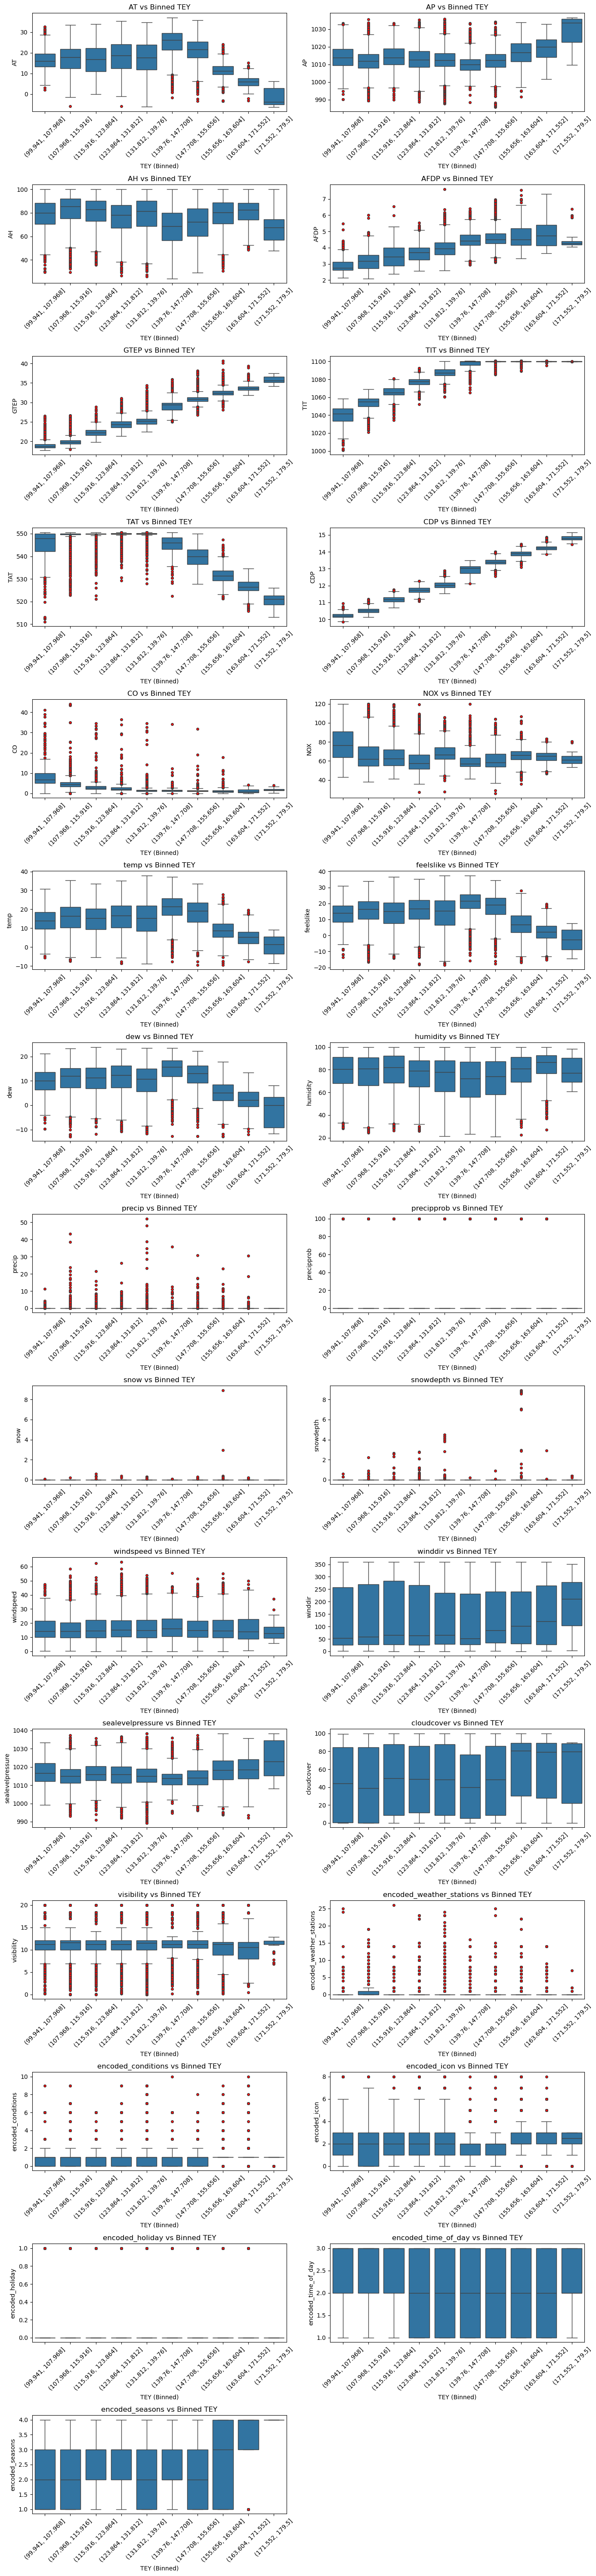

In [131]:
# Copy to avoid modifying original
binned_df = df_cleaned.copy()

# Select numeric columns
numeric_cols = binned_df.select_dtypes(include='number').columns.tolist()

# Remove TEY from features
numeric_cols.remove('TEY')

# Bin TEY into 10 bins
binned_df['TEY_bin'] = pd.cut(binned_df['TEY'], bins=10)

# Outlier styling
flierprops = dict(marker='o', markerfacecolor='red', markersize=4, linestyle='none')

# Subplot layout
n_features = len(numeric_cols)
n_cols = 2
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        x='TEY_bin',
        y=col,
        data=binned_df,
        ax=axes[i],
        flierprops=flierprops
    )
    axes[i].set_title(f'{col} vs Binned TEY')
    axes[i].set_xlabel('TEY (Binned)')
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Over and under 140  W TEY AT, AP Analysis
High R² (closer to 1) indicates strong linear correlation between predictors and the target.

t-value: indicates how strongly a predictor is associated with the target.

p-value: small (<0.05) suggests the predictor is significantly correlated with the target.

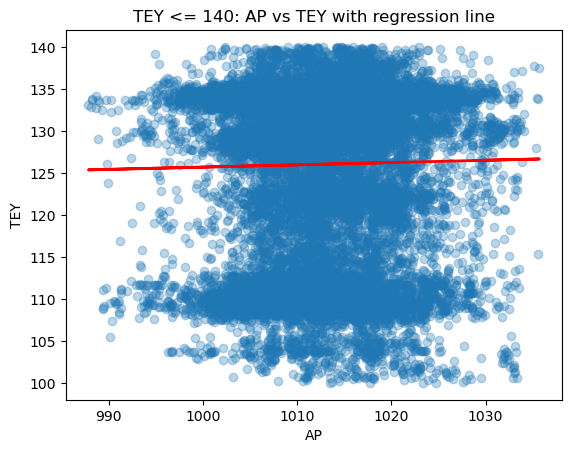

                            OLS Regression Results                            
Dep. Variable:                    TEY   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     7.292
Date:                Tue, 17 Feb 2026   Prob (F-statistic):            0.00693
Time:                        08:43:07   Log-Likelihood:                -98473.
No. Observations:               26252   AIC:                         1.970e+05
Df Residuals:                   26250   BIC:                         1.970e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         98.5974     10.166      9.699      0.0

In [135]:
# Subset for low TEY vs AP
low = df_cleaned[df_cleaned['TEY'] <= 140]

# Regression
X = smo.add_constant(low['AP'])  # adds intercept
y = low['TEY']
model = smo.OLS(y, X).fit()

# Predicted line
pred = model.predict(X)

# Plot
plt.scatter(low['AP'], low['TEY'], alpha=0.3)
plt.plot(low['AP'], pred, color='red', linewidth=2)  # regression line
plt.xlabel('AP')
plt.ylabel('TEY')
plt.title('TEY <= 140: AP vs TEY with regression line')
plt.show()
# Check slope
print(model.summary())

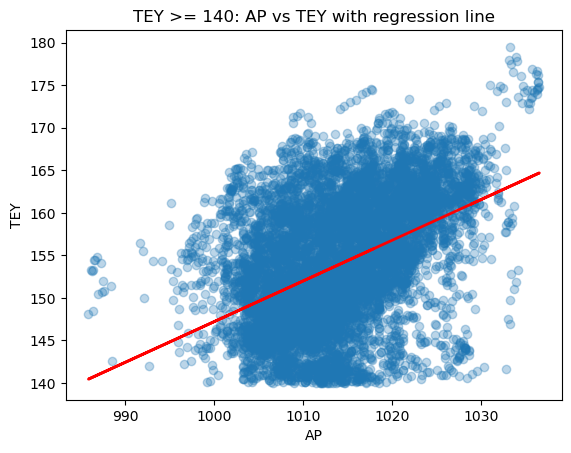

                            OLS Regression Results                            
Dep. Variable:                    TEY   R-squared:                       0.203
Model:                            OLS   Adj. R-squared:                  0.203
Method:                 Least Squares   F-statistic:                     2514.
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        08:43:35   Log-Likelihood:                -32392.
No. Observations:                9848   AIC:                         6.479e+04
Df Residuals:                    9846   BIC:                         6.480e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -330.4683      9.658    -34.216      0.0

In [137]:
# Subset for high TEY vs AP
high_TEY = df_cleaned[df_cleaned['TEY'] >= 140]

# Regression
X = smo.add_constant(high_TEY['AP'])
y = high_TEY['TEY']
model = smo.OLS(y, X).fit()
pred = model.predict(X)

# Plot
plt.scatter(high_TEY['AP'], high_TEY['TEY'], alpha=0.3)
plt.plot(high_TEY['AP'], pred, color='red', linewidth=2)  # regression line
plt.xlabel('AP')
plt.ylabel('TEY')
plt.title('TEY >= 140: AP vs TEY with regression line')
plt.show()

# Check slope
print(model.summary())

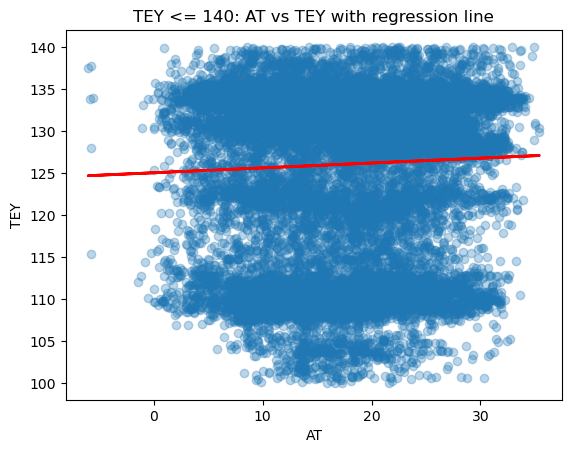

                            OLS Regression Results                            
Dep. Variable:                    TEY   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     42.36
Date:                Tue, 17 Feb 2026   Prob (F-statistic):           7.72e-11
Time:                        08:44:05   Log-Likelihood:                -98456.
No. Observations:               26252   AIC:                         1.969e+05
Df Residuals:                   26250   BIC:                         1.969e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        125.0259      0.170    737.511      0.0

In [138]:
# Subset for low TEY vs AT
low = df_cleaned[df_cleaned['TEY'] <= 140]

# Regression
X = smo.add_constant(low['AT'])  # adds intercept
y = low['TEY']
model = smo.OLS(y, X).fit()

# Predicted line
pred = model.predict(X)

# Plot
plt.scatter(low['AT'], low['TEY'], alpha=0.3)
plt.plot(low['AT'], pred, color='red', linewidth=2)  # regression line
plt.xlabel('AT')
plt.ylabel('TEY')
plt.title('TEY <= 140: AT vs TEY with regression line')
plt.show()
# Check slope
print(model.summary())

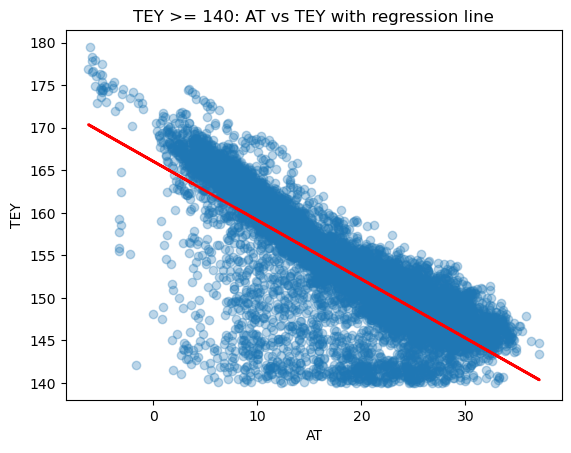

                            OLS Regression Results                            
Dep. Variable:                    TEY   R-squared:                       0.623
Model:                            OLS   Adj. R-squared:                  0.623
Method:                 Least Squares   F-statistic:                 1.628e+04
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        08:45:20   Log-Likelihood:                -28706.
No. Observations:                9848   AIC:                         5.742e+04
Df Residuals:                    9846   BIC:                         5.743e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        166.0460      0.106   1564.151      0.0

In [140]:
# Subset for high TEY vs AT
high_TEY = df_cleaned[df_cleaned['TEY'] >= 140]

# Regression
X = smo.add_constant(high_TEY['AT'])
y = high_TEY['TEY']
model = smo.OLS(y, X).fit()
pred = model.predict(X)

# Plot
plt.scatter(high_TEY['AT'], high_TEY['TEY'], alpha=0.3)
plt.plot(high_TEY['AT'], pred, color='red', linewidth=2)  # regression line
plt.xlabel('AT')
plt.ylabel('TEY')
plt.title('TEY >= 140: AT vs TEY with regression line')
plt.show()

# Check slope
print(model.summary())

# Physical turbine behavior: Gas turbines need sufficient inlet temperature, pressure, and air flow to reach high energy yields.

# Below a threshold (140kW), these factors may not limit output, so no clear correlation exists.

This is consistent with operating data: in many plants, output must go above a certain threshold (~120–140 MW) before turbine inlet and exhaust conditions strongly affect power output.

"Combined cycle power plants and gas turbines are known to exhibit rapid performance degradation when load is reduced, meaning they operate less efficiently and their output becomes less sensitive to changes in operating conditions (such as temperature and pressure) at lower loads. At part‑load conditions, both gas turbine and combined cycle efficiency fall off significantly compared to design or higher load conditions."
https://doi.org/10.1115/1.2814120 


## Possible adaptive model
Stage 1 (“quick model”): Use a fast classifier or regressor on the input features to predict whether the upcoming TEY is likely to be above 140 kW. This doesn’t need to be extremely accurate, just good enough to separate “low” vs “high” TEY regimes.

Stage 2 (“accurate model”): Use a more detailed model (Random Forest, Gradient Boosting, or whatever you choose) trained only on high-TEY data to predict the exact TEY value. Optionally, a separate model could handle low-TEY predictions if needed.

# Time series analysis of TEY values
Clear trends (up/down) → time matters

Seasonality (repeating patterns) → time matters

Sudden jumps → may need time-aware split

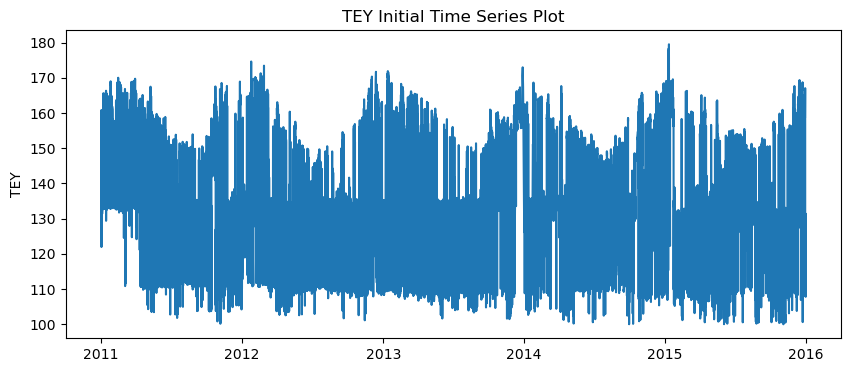

In [143]:
# Plot initial TEY timeseries
plt.figure(figsize=(10,4))
plt.plot(df_cleaned['DT'], df_cleaned['TEY']) 
plt.ylabel('TEY')
plt.title('TEY Initial Time Series Plot')
plt.show()

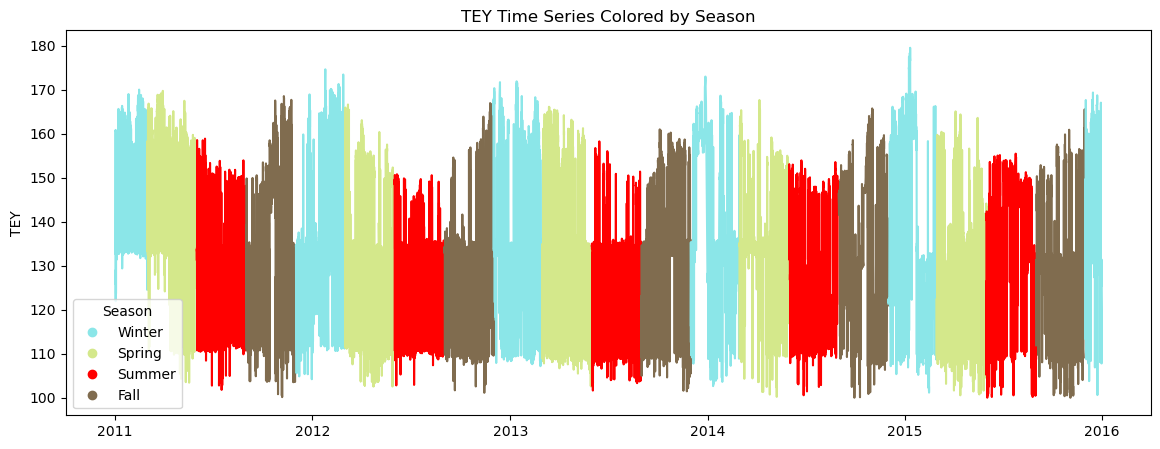

Fall 2011: high=168.52, low=100.17, mean=132.80
Fall 2012: high=166.94, low=101.15, mean=130.34
Fall 2013: high=160.97, low=101.48, mean=134.09
Fall 2014: high=165.73, low=100.03, mean=130.69
Fall 2015: high=165.53, low=100.02, mean=129.22

Winter 2011: high=170.00, low=104.23, mean=140.00
Winter 2012: high=174.61, low=107.92, mean=143.06
Winter 2013: high=172.96, low=107.20, mean=140.69
Winter 2014: high=168.63, low=102.67, mean=134.57
Winter 2015: high=179.50, low=100.64, mean=139.85

Spring 2011: high=169.72, low=103.45, mean=141.10
Spring 2012: high=166.62, low=102.56, mean=131.35
Spring 2013: high=166.10, low=102.55, mean=130.90
Spring 2014: high=167.64, low=100.22, mean=136.66
Spring 2015: high=165.06, low=100.58, mean=128.78

Summer 2011: high=158.87, low=101.81, mean=131.01
Summer 2012: high=150.78, low=102.83, mean=129.43
Summer 2013: high=158.25, low=101.66, mean=127.56
Summer 2014: high=153.93, low=100.59, mean=130.46
Summer 2015: high=155.46, low=100.04, mean=139.51



In [144]:
# Ensure DT is datetime
df_cleaned['DT'] = pd.to_datetime(df_cleaned['DT'])

# Extract year
df_cleaned['year'] = df_cleaned['DT'].dt.year

# Map months to seasons
def get_season(date):
    m = date.month
    if m in [12, 1, 2]:
        return 'Winter'
    elif m in [3, 4, 5]:
        return 'Spring'
    elif m in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df_cleaned['season'] = df_cleaned['DT'].apply(get_season)

# Map colors
season_colors = {'Winter': '#8BE6E8', 'Spring': '#D4E88B', 'Summer': 'red', 'Fall': '#806C4F'}

dates = df_cleaned['DT']
tey = df_cleaned['TEY']
seasons = df_cleaned['season']

plt.figure(figsize=(14,5))

# Plot line segment by segment where the season is the same
start_idx = 0
for i in range(1, len(dates)):
    if seasons.iloc[i] != seasons.iloc[start_idx]:
        plt.plot(dates.iloc[start_idx:i+1], tey.iloc[start_idx:i+1], 
                 color=season_colors[seasons.iloc[start_idx]])
        start_idx = i
plt.plot(dates.iloc[start_idx:], tey.iloc[start_idx:], color=season_colors[seasons.iloc[start_idx]])

# Add legend manually
for season, color in season_colors.items():
    plt.plot([], [], color=color, marker='o', linestyle='', label=season)
plt.legend(title="Season")

plt.ylabel('TEY')
plt.title('TEY Time Series Colored by Season')
plt.show()

# --- Print high, low, mean per season per year in ordered format ---
summary = df_cleaned.copy()
summary['TEY'] = df_cleaned['TEY']

# Define season order
season_order = ['Fall', 'Winter', 'Spring', 'Summer']

# Loop through seasons first, then years
for season in season_order:
    season_data = summary[summary['season'] == season]
    for year in sorted(season_data['year'].unique()):
        group = season_data[season_data['year'] == year]
        if not group.empty:
            high = group['TEY'].max()
            low = group['TEY'].min()
            mean = group['TEY'].mean()
            print(f"{season} {year}: high={high:.2f}, low={low:.2f}, mean={mean:.2f}")
    print() 

# Highest high values are acheived in Winter, lowest high values in summer

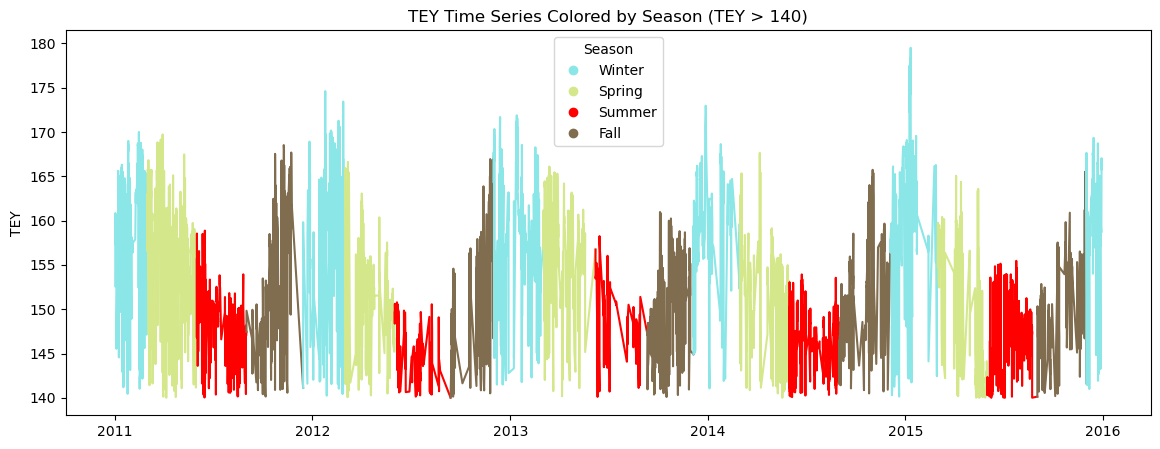

Fall 2011: high=168.52, low=140.15, mean=155.10
Fall 2012: high=166.94, low=140.03, mean=154.97
Fall 2013: high=160.97, low=140.10, mean=152.03
Fall 2014: high=165.73, low=140.50, mean=150.56
Fall 2015: high=165.53, low=140.14, mean=150.50

Winter 2011: high=170.00, low=140.46, mean=160.56
Winter 2012: high=174.61, low=140.25, mean=161.33
Winter 2013: high=172.96, low=141.78, mean=160.45
Winter 2014: high=168.63, low=140.15, mean=159.12
Winter 2015: high=179.50, low=141.00, mean=162.04

Spring 2011: high=169.72, low=140.01, mean=157.94
Spring 2012: high=166.62, low=140.07, mean=153.86
Spring 2013: high=166.10, low=140.19, mean=158.67
Spring 2014: high=167.64, low=140.01, mean=152.13
Spring 2015: high=165.06, low=140.02, mean=149.69

Summer 2011: high=158.87, low=140.04, mean=148.51
Summer 2012: high=150.78, low=140.14, mean=146.11
Summer 2013: high=158.25, low=140.11, mean=148.88
Summer 2014: high=153.93, low=140.09, mean=147.08
Summer 2015: high=155.46, low=140.01, mean=148.00

Total 

In [145]:
# Ensure DT is datetime
df_cleaned['DT'] = pd.to_datetime(df_cleaned['DT'])

# Extract year
df_cleaned['year'] = df_cleaned['DT'].dt.year

# Map months to seasons
def get_season(date):
    m = date.month
    if m in [12, 1, 2]:
        return 'Winter'
    elif m in [3, 4, 5]:
        return 'Spring'
    elif m in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df_cleaned['season'] = df_cleaned['DT'].apply(get_season)

# Map colors
season_colors = {'Winter': '#8BE6E8', 'Spring': '#D4E88B', 'Summer': 'red', 'Fall': '#806C4F'}

# Filter for TEY > 140
df_high_TEY = df_cleaned[df_cleaned['TEY'] > 140].copy()

dates = df_high_TEY['DT']
tey = df_high_TEY['TEY']
seasons = df_high_TEY['season']

plt.figure(figsize=(14,5))

# Plot line segment by segment where the season is the same
start_idx = 0
for i in range(1, len(dates)):
    if seasons.iloc[i] != seasons.iloc[start_idx]:
        plt.plot(dates.iloc[start_idx:i+1], tey.iloc[start_idx:i+1], 
                 color=season_colors[seasons.iloc[start_idx]])
        start_idx = i
plt.plot(dates.iloc[start_idx:], tey.iloc[start_idx:], color=season_colors[seasons.iloc[start_idx]])

# Add legend manually
for season, color in season_colors.items():
    plt.plot([], [], color=color, marker='o', linestyle='', label=season)
plt.legend(title="Season")

plt.ylabel('TEY')
plt.title('TEY Time Series Colored by Season (TEY > 140)')
plt.show()

# --- Print high, low, mean per season per year for TEY > 140 ---
summary = df_high_TEY.copy()

# Define season order
season_order = ['Fall', 'Winter', 'Spring', 'Summer']

# Loop through seasons first, then years
for season in season_order:
    season_data = summary[summary['season'] == season]
    for year in sorted(season_data['year'].unique()):
        group = season_data[season_data['year'] == year]
        if not group.empty:
            high = group['TEY'].max()
            low = group['TEY'].min()
            mean = group['TEY'].mean()
            print(f"{season} {year}: high={high:.2f}, low={low:.2f}, mean={mean:.2f}")
    print()
print(f'Total high TEY values: {df_high_TEY.shape[0]}')

# QQ Plot for Y = TEY

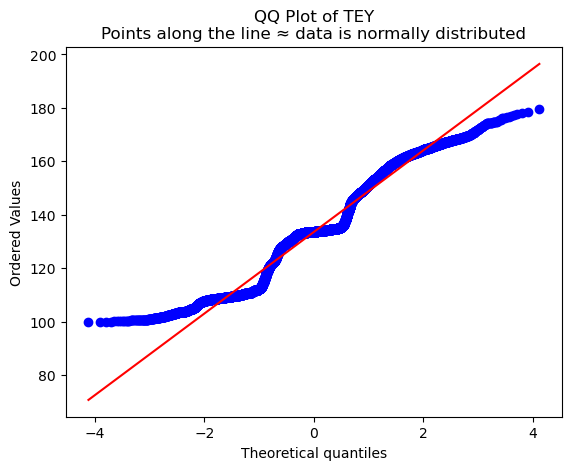

In [148]:
# Drop NaNs just in case
tey = df_cleaned['TEY'].dropna()

stats.probplot(tey, dist="norm", plot=plt)
plt.title("QQ Plot of TEY\nPoints along the line ≈ data is normally distributed", fontsize=12)
plt.show()

# SHAP value analysis

Feature Importance: Features are ranked vertically by their total impact.

Impact: The horizontal axis shows how much a feature moved the prediction higher (positive SHAP) or lower (negative SHAP).

Feature Value: The color (Red for High, Blue for Low) represents the actual value of that feature for a specific observation.

SHAP captures:

Non-Linearity: How a feature's impact changes at different thresholds.

Interactions: How the influence of one feature depends on the values of others.

SHAP explains how each individual data point reached its specific prediction.

###### (Markdown SHAP Value explanation enhanced via Google Gemini)

SHAP Training started...
SHAP Training complete.


Calculating SHAP: 100%|██████████| 7220/7220 [1:38:35<00:00,  1.22it/s]


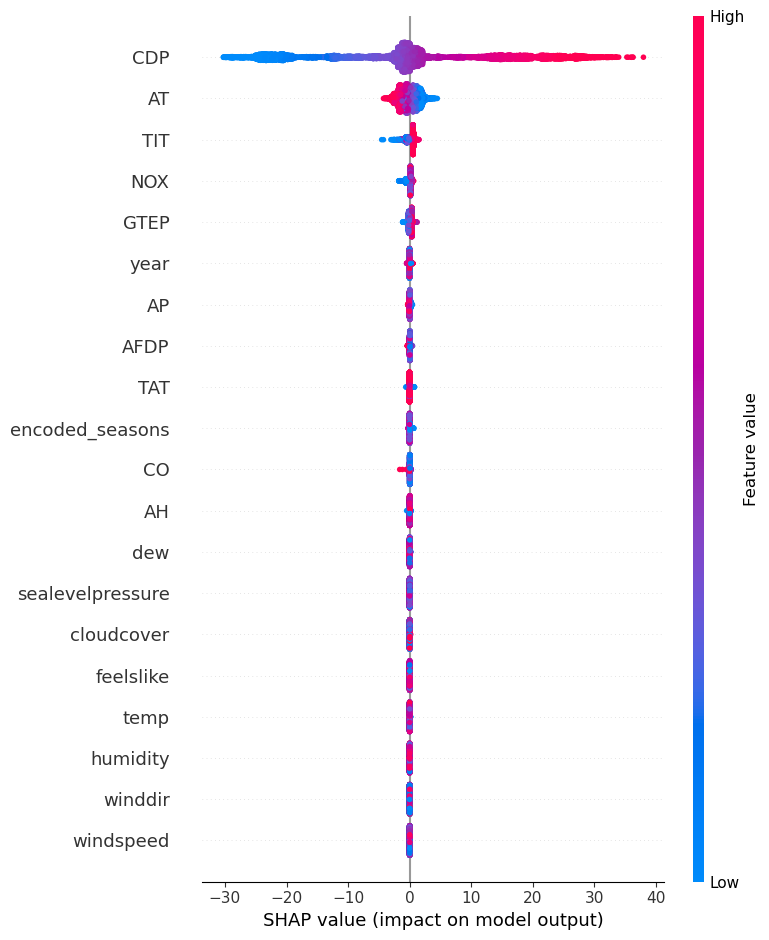

In [156]:
# Prepare features and target

# Drop DT, holiday string columns, and dependent variable TEY from X
X = df_cleaned.drop(columns=['DT', 'TEY'] + 
                            [col for col in df_cleaned.columns if col.startswith('holiday_') and df_cleaned[col].dtype == object], 
                            errors='ignore')

# Keep only numeric columns
X = X.select_dtypes(include='number')

# Impute possible missing values with column mean
X_filled = X.fillna(X.mean())

y = df_cleaned['TEY']

#  Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_filled, y, test_size=0.2, random_state=42)

#  Train a RandomForest model (100 trees)
model = RandomForestRegressor(n_estimators=100, random_state=42)
print("SHAP Training started...")
model.fit(X_train, y_train)
print("SHAP Training complete.")

# Explain with SHAP with progress bar
explainer = shap.TreeExplainer(model)

shap_values = []
for i in tqdm(range(X_test.shape[0]), desc="Calculating SHAP"):
    sv = explainer.shap_values(X_test.iloc[i:i+1])
    shap_values.append(sv[0])

shap_values = np.vstack(shap_values)

# Summary plot
shap.summary_plot(shap_values, X_test)

CDP = Compressor discharge pressure
<br>"Higher compressor pressure ratio increases gas turbine power output and overall cycle efficiency.
Studies show that increasing the pressure ratio — which is directly related to compressor discharge pressure — lowers exergy destruction and raises power output in combined cycle power plants, because higher pressure enables more effective combustion and energy conversion."

https://doi.org/10.1016/j.csite.2022.102506

In [1]:
%%html

<p><b>Shutting down your kernel for this notebook to release resources.</b></p>
<button class="sm-command-button" data-commandlinker-command="kernelmenu:shutdown" style="display:none;">Shutdown Kernel</button>
        
<script>
try {
    els = document.getElementsByClassName("sm-command-button");
    els[0].click();
}
catch(err) {
    // NoOp
}    
</script>